In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score
import os

In [10]:
os.chdir(os.path.expanduser('~'))
os.chdir("/data/cmn_vamal/mwilson")

imaging_data = pd.read_csv("data/mri_toy_2/mri_toy_dataset/WMH_batch_results/extracted_csvs/combined_hypointensities.csv", index_col = 0)
imaging_data = imaging_data.T
imaging_data.index.name = ("MRI sample label")
imaging_data.columns.name = "Region of interest"
#print(imaging_data.head())
id_list = imaging_data.index.tolist()

full_metadata = pd.read_csv("data/ADNI_1_2_GO.csv")
metadata_50 = full_metadata[full_metadata["Image Data ID"].isin(id_list)]
metadata_50_AD = metadata_50[metadata_50["Group"] == "AD"]
ids = metadata_50_AD.iloc[:,0].tolist()
imaging_data_ad = (imaging_data.loc[ids])

print(metadata_50)


    Image Data ID     Subject Group Sex  Age Visit Modality Description  \
1          I13722  002_S_0295    CN   M   85    sc      MRI     MP-RAGE   
15         I14437  002_S_0413    CN   F   76    sc      MRI     MP-RAGE   
20         I15948  002_S_0559    CN   M   79    sc      MRI     MP-RAGE   
26         I16392  002_S_0619    AD   M   78    sc      MRI     MP-RAGE   
32         I18211  002_S_0685    CN   F   90    sc      MRI     MP-RAGE   
38         I23591  002_S_0816    AD   M   71    sc      MRI     MP-RAGE   
42         I25952  002_S_0938    AD   F   82    sc      MRI     MP-RAGE   
46         I26170  002_S_0955    AD   F   78    sc      MRI     MP-RAGE   
47         I30875  002_S_1018    AD   F   71    sc      MRI     MP-RAGE   
52         I40503  002_S_1261    CN   F   71    sc      MRI     MP-RAGE   
63         I40083  002_S_1280    CN   F   71    sc      MRI     MP-RAGE   
71        I254582  002_S_4213    CN   F   78   v02      MRI      MPRAGE   
81        I257270  002_S_

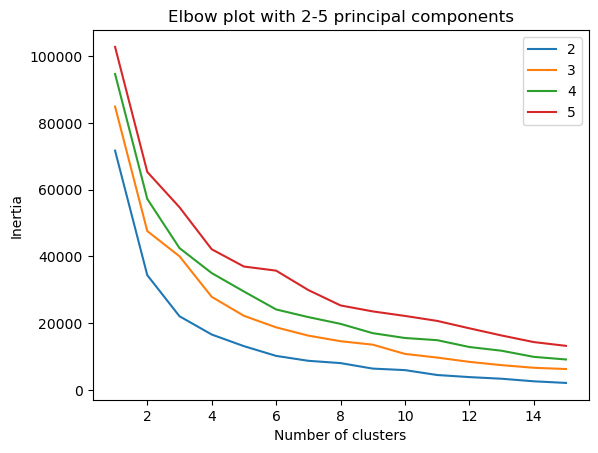

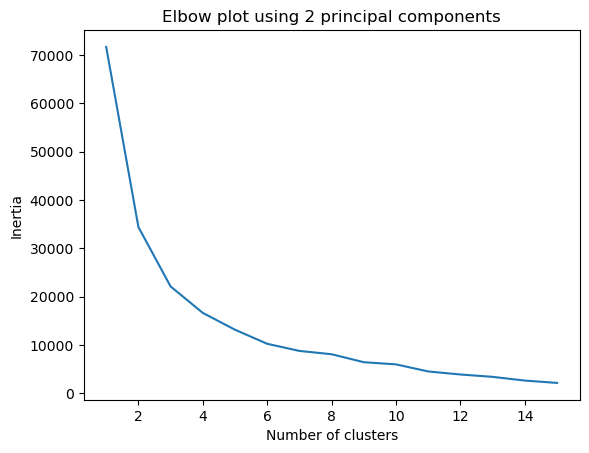

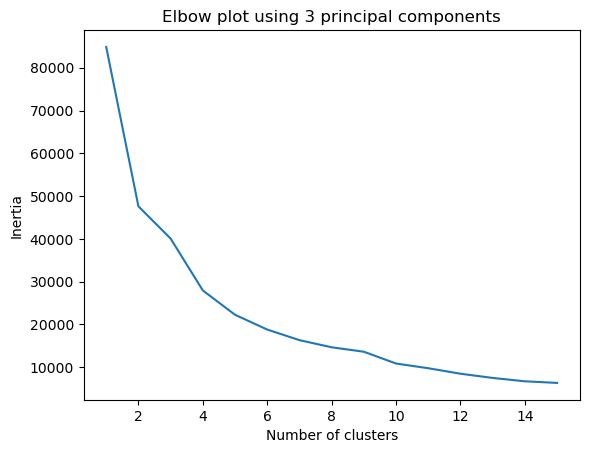

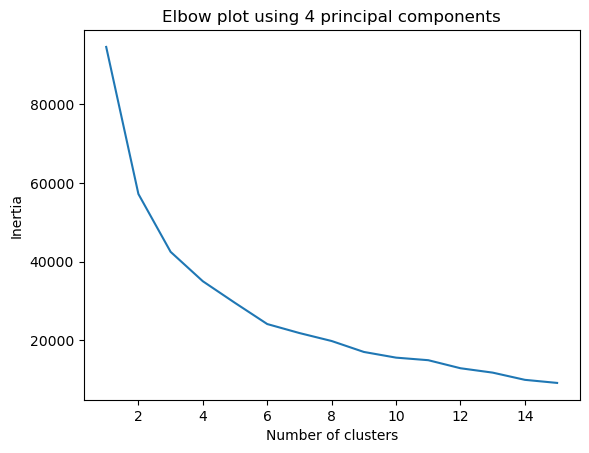

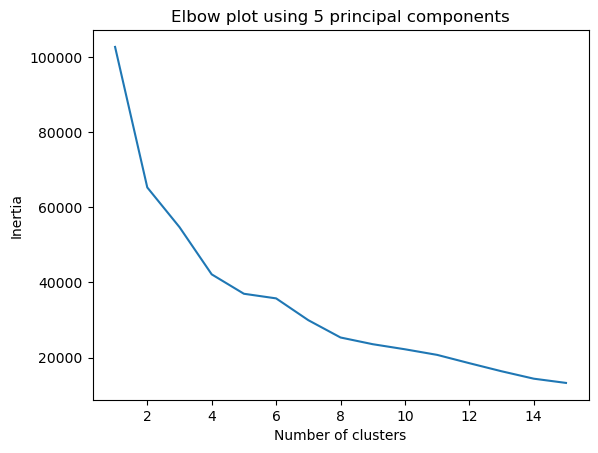

In [11]:
# Elbow plots 

k = np.arange(1,16,1)

for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
        a = (kmeans.inertia_)
        x.append(a)
    plt.plot(k, x, label = j+2)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.legend()
plt.title(f"Elbow plot with 2-5 principal components")
plt.show()

for j in range(4):    
    x = []
    for i in range(15):
        pca = PCA(n_components=j+2,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        kmeans = KMeans(n_clusters=i+1, random_state=0, n_init="auto").fit(pca_result)
        a = (kmeans.inertia_)
        x.append(a)
    plt.plot(k, x)
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.title(f"Elbow plot using {j+2} principal components")
    plt.show()

34401.0571832848


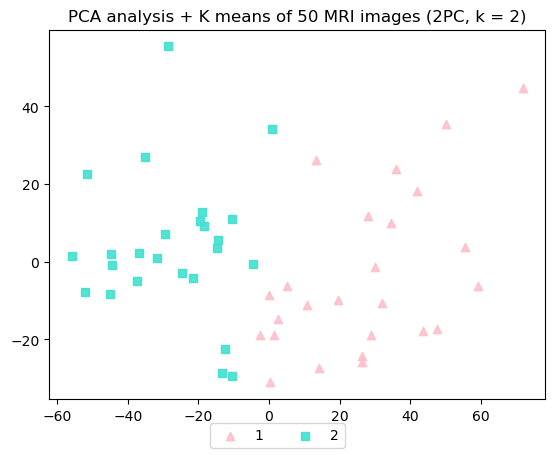

22099.17834419218


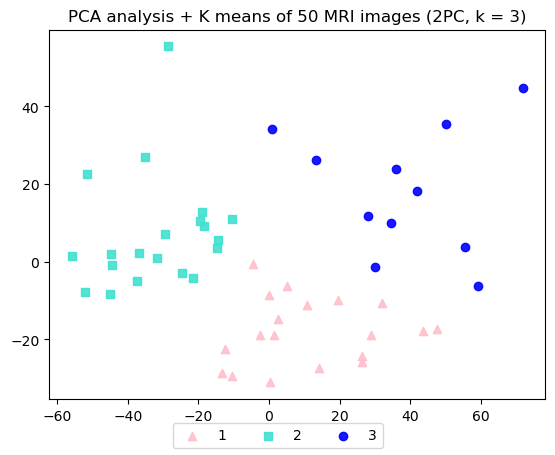

16627.65072221324


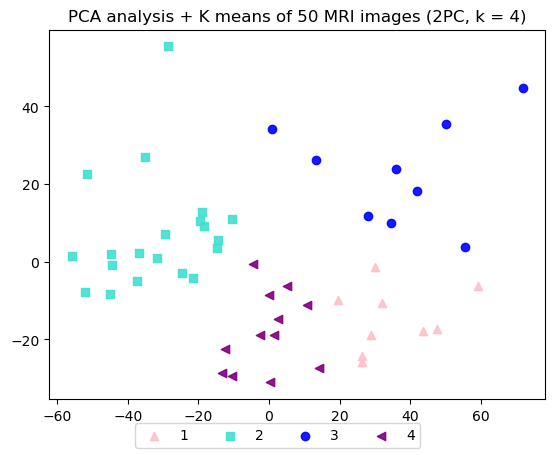

13145.467225616405


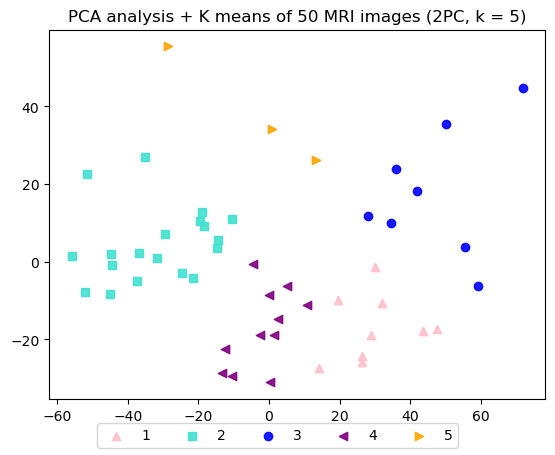

In [12]:
# 2 principal components 


fig, ax = plt.subplots()
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()


fig, ax = plt.subplots()
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()


fig, ax = plt.subplots()
pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)


kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_

for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )

plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))

plt.show()

fig, ax = plt.subplots()

pca = PCA(n_components=2,random_state=42)
pca_result = pca.fit_transform(imaging_data)


kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_

for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )

plt.title("PCA analysis + K means of 50 MRI images (2PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))

plt.show()

47597.5267549671


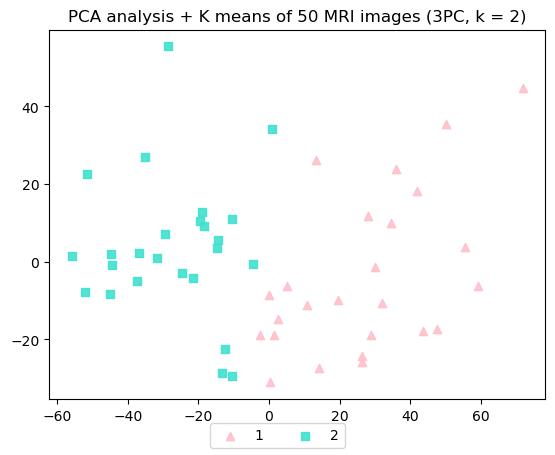

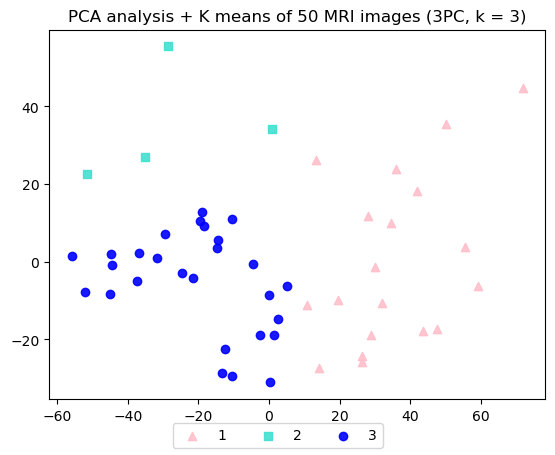

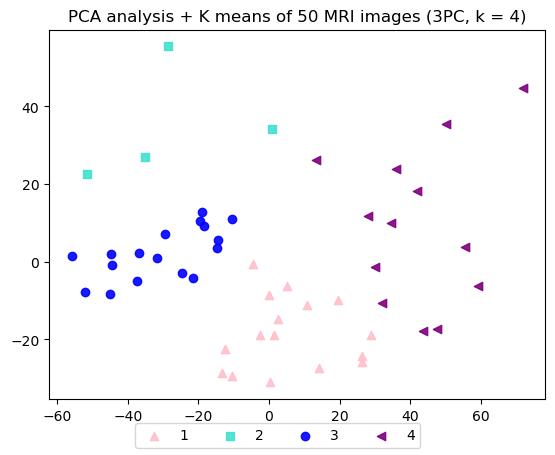

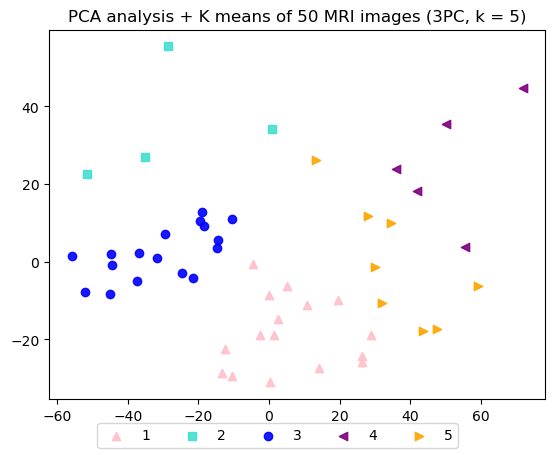

In [13]:
# 3 principal components 

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=3,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (3PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

57219.808666041055


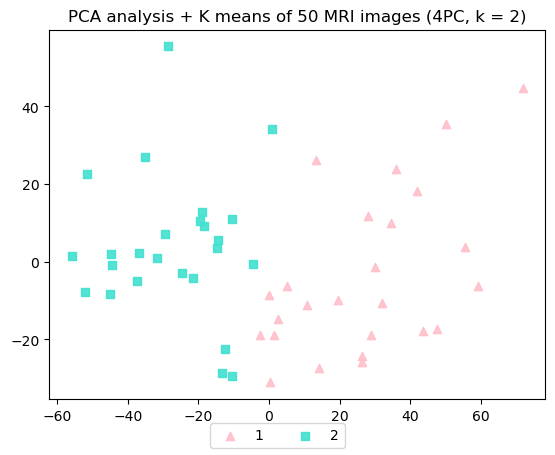

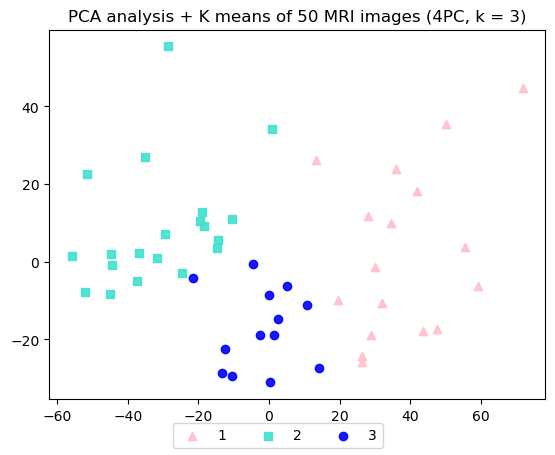

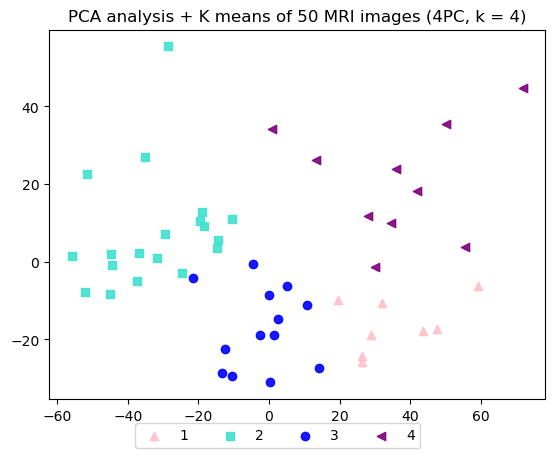

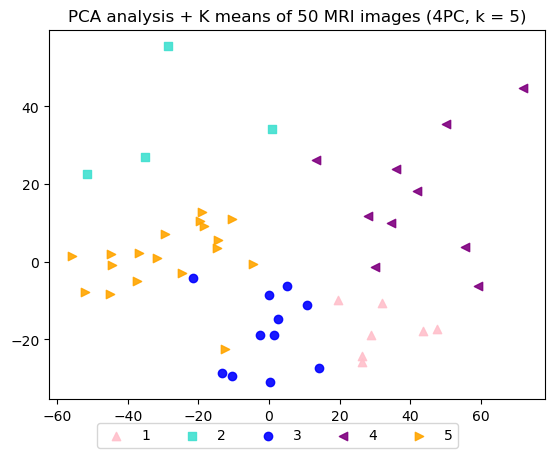

In [14]:
# 4 principal components 
fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()


fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 3)")
labels = [1,2,3]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

65297.67127271095


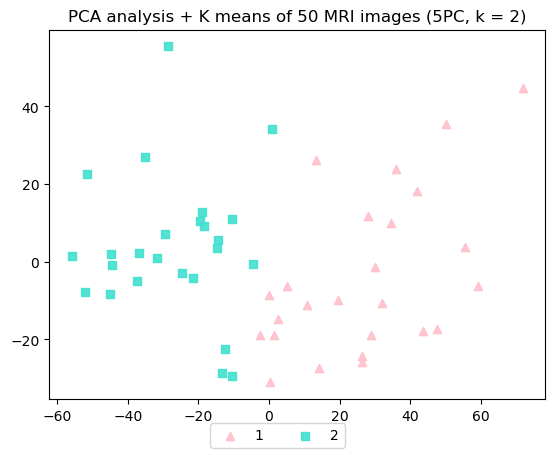

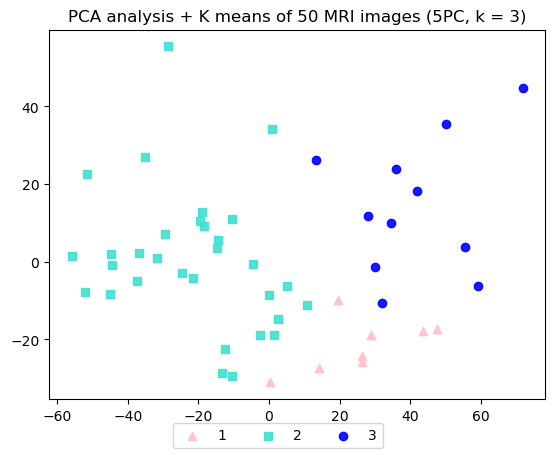

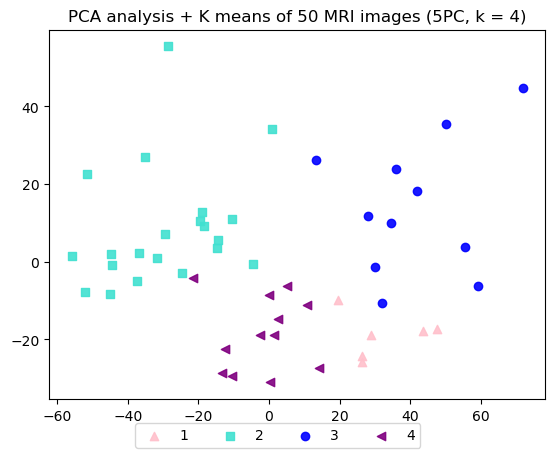

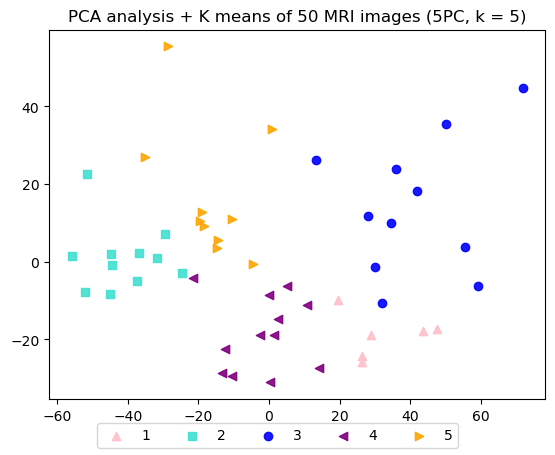

In [15]:
# 5 principal components 
fig, ax = plt.subplots()
pca = PCA(n_components=5,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
print(kmeans.inertia_)
y = kmeans.labels_
for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()



fig, ax = plt.subplots()
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 4)")
labels = [1,2,3,4]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

fig, ax = plt.subplots()
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 5)")
labels = [1,2,3,4,5]
fig.legend(labels, loc='lower center',ncol=len(labels))
plt.show()

In [16]:
# Adding in TSNE

[1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1
 0 1 1 1 1 1 0 0 0 1 0 0 0]


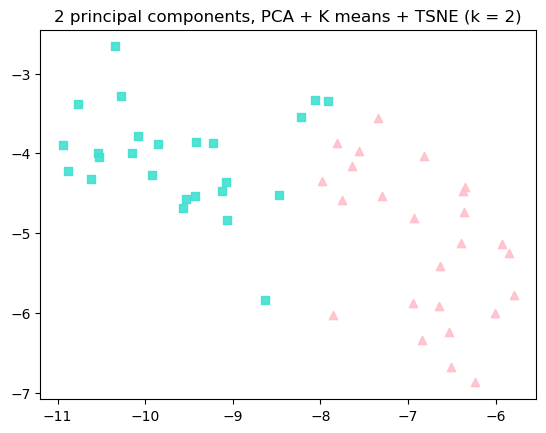

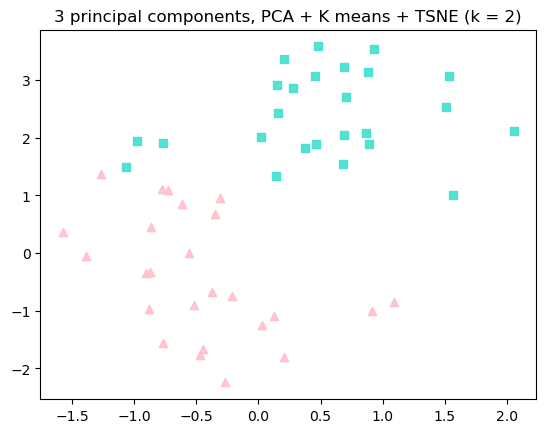

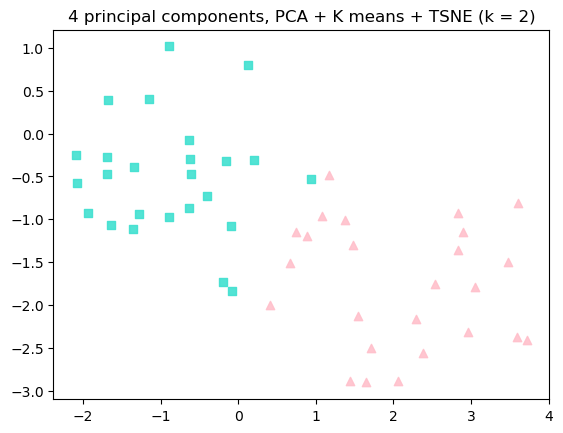

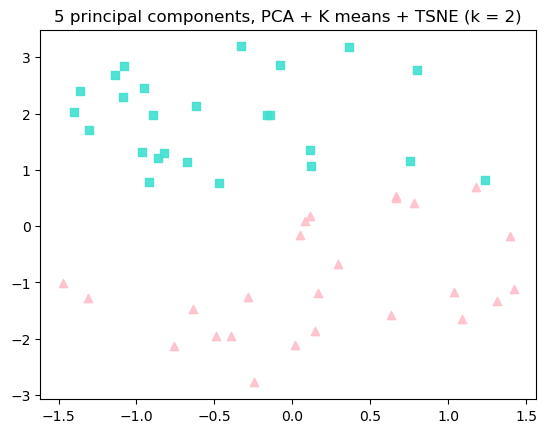

In [17]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 2)")
y = np.array(y)
print(y)

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 2)")



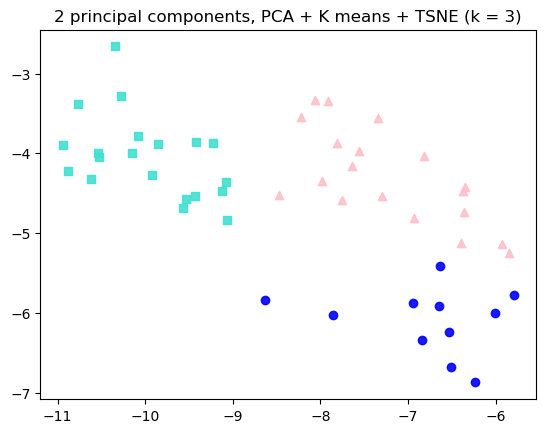

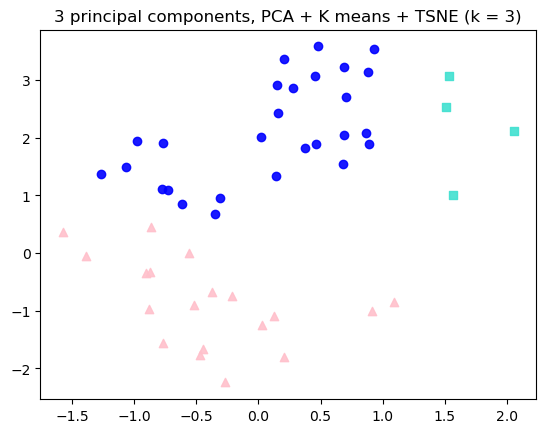

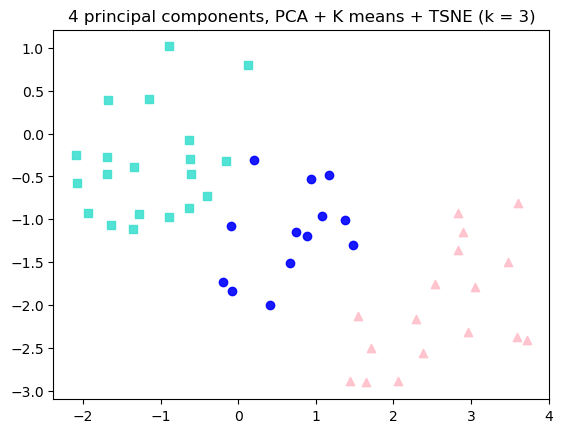

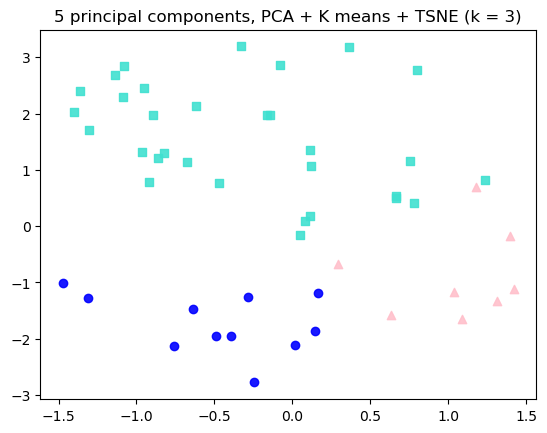

In [18]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 3)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2], ["pink", "turquoise", "blue"], ('^', 's', "o")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 3)")

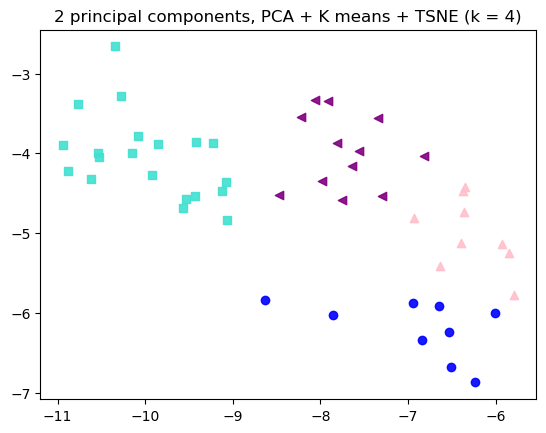

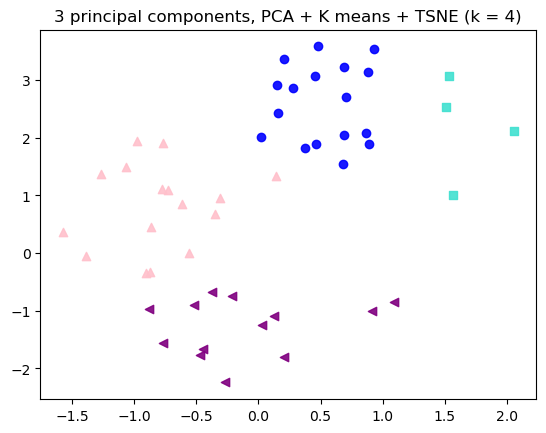

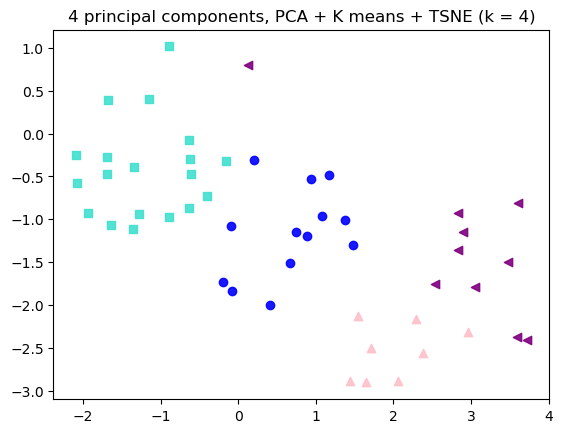

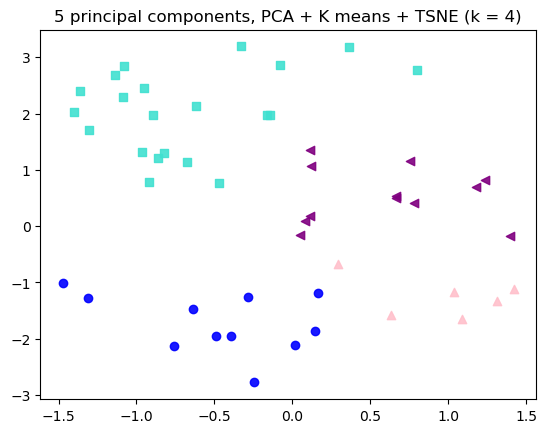

In [19]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 4)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2,3], ["pink", "turquoise", "blue", "purple"], ('^', 's', "o", "<")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 4)")


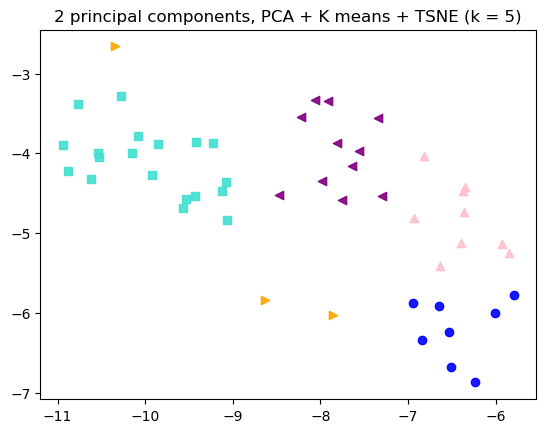

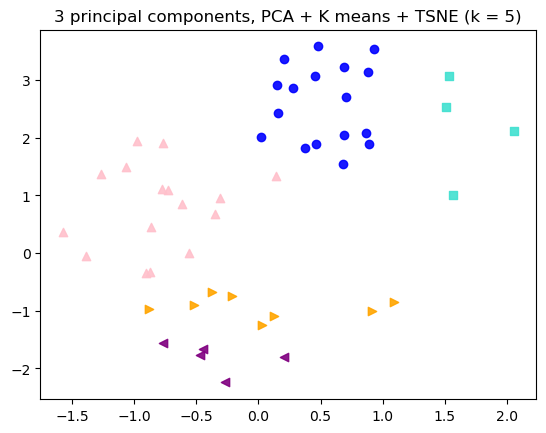

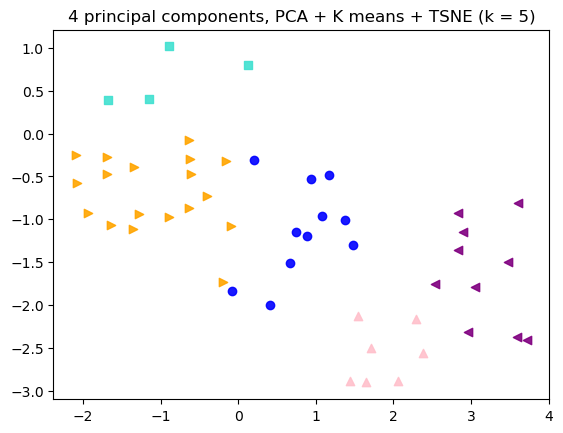

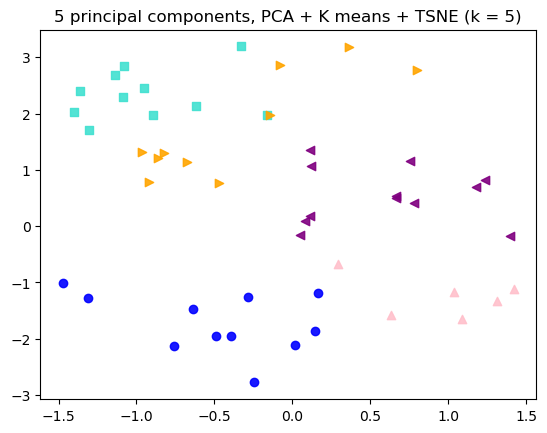

In [20]:
for i in range(2):
    pca = PCA(n_components=i+2,random_state=42)
    pca_result = pca.fit_transform(imaging_data)
    x = TSNE(n_components = 2).fit_transform(pca_result)
    kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
    y = kmeans.labels_    
    fig, ax = plt.subplots() 
    for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
        ax.scatter(x[y == l, 0],
                    x[y == l, 1],
                    color=c,
                    label='cluster %s' % l,
                    alpha=0.9,
                    marker=m
                    )
    plt.title(f"{i+2} principal components, PCA + K means + TSNE (k = 5)")

for i in range(4):
    a = i+2
    if a > 3:
        pca = PCA(n_components=a,random_state=42)
        pca_result = pca.fit_transform(imaging_data)
        x = TSNE(n_components = 2, method = "exact").fit_transform(pca_result)
        kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(pca_result)
        y = kmeans.labels_
        fig, ax = plt.subplots() 
        
        for l, c, m in zip([0,1,2,3,4], ["pink", "turquoise", "blue", "purple", "orange"], ('^', 's', "o", "<", ">")):
            ax.scatter(x[y == l, 0],
                        x[y == l, 1],
                        color=c,
                        label='cluster %s' % l,
                        alpha=0.9,
                        marker=m
                        )
        plt.title(f"{a} principal components, PCA + K means + TSNE (k = 5)")


Explained variance ratio: [0.34726748 0.12426576 0.08681924 0.06423032 0.05322407]
Total variance explained: 0.6758068767750416


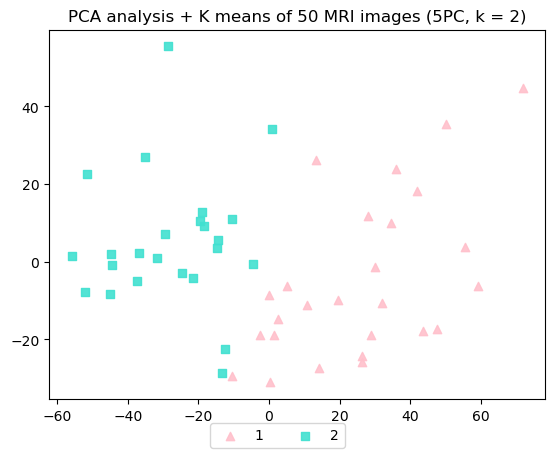

In [27]:
# Reporting clustering accuracy 

# Using k = 2 because want to compare groupings with AD/CN labels 

fig, ax = plt.subplots()
#pca = PCA(n_components=2,random_state=42)
pca = PCA(n_components=5)

pca_result = pca.fit_transform(imaging_data)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)}")
#kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
kmeans = KMeans(n_clusters=2, n_init="auto").fit(pca_result)

y = kmeans.labels_
#print(imaging_data.index)
#print(y)

for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
    
plt.title("PCA analysis + K means of 50 MRI images (5PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center', ncol=len(labels))
plt.show()

metadata_id_group = metadata_50.iloc[:, [0,2]]
metadata_2 = metadata_id_group.copy() 
metadata_2["Cluster"] = y

for i in range(50):
    a = metadata_2.iloc[i,1]
    if a == "CN":
        metadata_2.iloc[i,1] = int(0)
    else: 
        metadata_2.iloc[i,1] = int(1)

metadata_2.iloc[:,1] = metadata_2.iloc[:,1].values.astype("int32")
metadata_2.iloc[:,2] = metadata_2.iloc[:,2].values.astype("int32")

<class 'numpy.ndarray'>


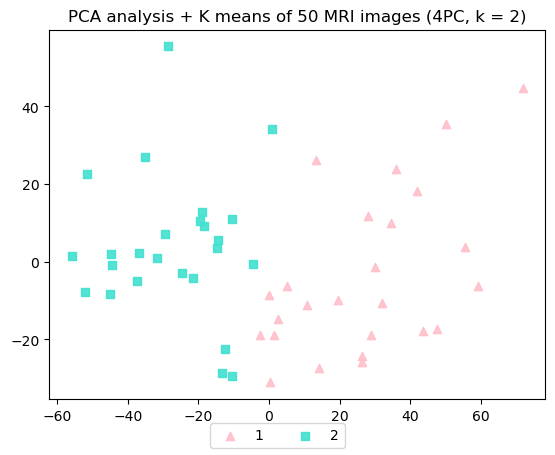

object
int64
<class 'int'>
<class 'numpy.int64'>


ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [39]:
# Reporting clustering accuracy 

# Using k = 2 because want to compare groupings with AD/CN labels 

fig, ax = plt.subplots()
pca = PCA(n_components=4,random_state=42)
pca_result = pca.fit_transform(imaging_data)
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(pca_result)
y = kmeans.labels_
#print(imaging_data.index)
#print(y)
np.savetxt('results/pca_clusters.csv', y, fmt='%d', delimiter=',')
print(type(y))

for l, c, m in zip([0,1], ["pink", "turquoise"], ('^', 's')):
    ax.scatter(pca_result[y == l, 0],
                pca_result[y == l, 1],
                color=c,
                label='cluster %s' % l,
                alpha=0.9,
                marker=m
                )
plt.title("PCA analysis + K means of 50 MRI images (4PC, k = 2)")
labels = [1,2]
fig.legend(labels, loc='lower center', ncol=len(labels))
plt.show()

y_true = np.zeros(50)
for i in range(len(metadata_50)):
    if metadata_50.iloc[i,2]== "CN":
        y_true[i] = int(0)
    else:
        y_true[i] = 1
metadata_2.iloc[:,1] = pd.to_numeric(metadata_2.iloc[:,1])
metadata_2.iloc[:,1] = metadata_2.iloc[:,1].values.astype(int)
metadata_2.iloc[:,2] = metadata_2.iloc[:,2].values.astype(int)


metadata_2 = metadata_2.reset_index(drop=True)

print(metadata_2.iloc[:,1].dtype)
print(metadata_2.iloc[:,2].dtype)
print(type(metadata_2.iloc[:,1].values[0]))
print(type(metadata_2.iloc[:,2].values[0]))

accuracy_score(metadata_2.iloc[:,1], metadata_2.iloc[:,2])


In [29]:
a = metadata_50.iloc[:,[2]]
for i in range(50):
    if a.iloc[i,0] == "CN":
        a.iloc[i,0] = 0
    else: 
        a.iloc[i,0] = 1

a.iloc[:,0] = a.iloc[:,0].astype(int)
y = y.astype(int)

print(type(a.iloc[1,0]))
print(type(y[1]))

<class 'int'>
<class 'numpy.int64'>


/tmp/ipykernel_2352537/3045549438.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 0
/tmp/ipykernel_2352537/3045549438.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a.iloc[i,0] = 1


In [8]:
for i in range(11):
    pca = PCA(n_components=i+2)
    pca_result = pca.fit_transform(imaging_data)
    kmeans = KMeans(n_clusters=2, n_init="auto").fit(pca_result)
    y = kmeans.labels_
    print(f"Accuracy when PC = {i+2}: {accuracy_score(a, y)}")
print(len(y))
y.to_csv("results/pca_clusters")

InvalidParameterError: The 'y_true' parameter of accuracy_score must be an array-like or a sparse matrix. Got 'AD' instead.